In [1]:
import numpy as np
import mmcfilters
import matplotlib
import math
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (16,16)

from IPython import display
from os import listdir
import cv2 as cv

np.set_printoptions(suppress=True) 

In [3]:
from PrettyPrint import PrettyPrintTree
from colorama import Fore, Back
printTree = PrettyPrintTree(
    lambda node: node.children,
#    lambda node: ("id:" + str(node.id) + " " + str(node.isMaxtree)[0], "level:" + str(node.level) + " (" + str(node.residue) + ")", "|cnps|:" + str(len(node.cnps))  ), 
    lambda node: ("id:" + str(node.id) ), 
    color=Back.BLACK + Fore.WHITE
)



In [5]:
#imgInput = cv.imread("../dat/imgTeste.png", cv.IMREAD_GRAYSCALE)
imgInput = cv.imread("../dat/imgObjetos.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/cable.png", cv.IMREAD_GRAYSCALE)
#imgInput = cv.imread("../dat/images/peppers_gray.tif", cv.IMREAD_GRAYSCALE)

(num_rows, num_cols) = imgInput.shape



In [11]:
import pandas as pd
ok = True
trainset = ["../dat/imgTeste.png", "../dat/imgObjetos.png", "../dat/cable.png"]
for i in range(len(trainset)):
    img = cv.imread(trainset[i], cv.IMREAD_GRAYSCALE)
    (img_rows, img_cols) = img.shape
    tree = mmcfilters.MorphologicalTree(img.ravel(), img_rows, img_cols)
    features, attrs = mmcfilters.Attribute.computeAttributes(tree, [mmcfilters.Attribute.ALL])
    
    df2 = pd.DataFrame(attrs, columns=features)
    if( len( df2[df2.isna().any(axis=1)]  ) > 0 ):
        print(i, df2[df2.isna().any(axis=1)] )
        ok = False
    #else:
    #    display.display(df2)
if(ok):
    print("Atributos verificados, tudo ok!")


==== AttributeComputer: Computing AREA

==== AttributeComputer: Computing VOLUME

==== AttributeComputer: Computing GrayLevelStatsComputer 

==== AttributeComputer: Computing BOUNDING_BOX group

==== AttributeComputer: Computing CENTRAL_MOMENT group

==== AttributeComputer: Computing MOMENT_BASED group

==== AttributeComputer: Computing HU_MOMENT group

==== AttributeComputer: Computing STRUCTURE_TREE group

==== AttributeComputer: Computing AREA

==== AttributeComputer: Computing VOLUME

==== AttributeComputer: Computing GrayLevelStatsComputer 

==== AttributeComputer: Computing BOUNDING_BOX group

==== AttributeComputer: Computing CENTRAL_MOMENT group

==== AttributeComputer: Computing MOMENT_BASED group

==== AttributeComputer: Computing HU_MOMENT group

==== AttributeComputer: Computing STRUCTURE_TREE group

==== AttributeComputer: Computing AREA

==== AttributeComputer: Computing VOLUME

==== AttributeComputer: Computing GrayLevelStatsComputer 

==== AttributeComputer: Computing 

In [17]:
maxtree = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols, True, 1.5)
mintree = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols, False, 1.5)
tos = mmcfilters.MorphologicalTree(imgInput, num_rows, num_cols)

filterMaxtree = mmcfilters.AttributeFilters(maxtree)
filterMintree = mmcfilters.AttributeFilters(mintree)
filterToS = mmcfilters.AttributeFilters(tos)


In [ ]:
def plotCountors(pixels, node, num_rows, num_cols):
    contour_img = np.zeros((num_rows, num_cols), dtype=np.uint8)
    
    for p in pixels:
        row = p // num_cols
        col = p % num_cols
        contour_img[row, col] = 255  
    
    # Plotar com matplotlib
    plt.figure(figsize=(5, 5))
    plt.imshow(contour_img, cmap='Reds')
    plt.title(node)
    plt.axis('off')
    plt.show()

countors = mmcfilters.Attribute.extractCountors(tos)
nodes = tos.listNodes
for node in nodes:
    if (node.area > 10000):
        plotCountors(countors[node.id], node, num_rows, num_cols)


==== AttributeComputer: Computing VOLUME

==== AttributeComputer: Computing GrayLevelStatsComputer 

==== AttributeComputer: Computing VOLUME

==== AttributeComputer: Computing GrayLevelStatsComputer 

==== AttributeComputer: Computing VOLUME

==== AttributeComputer: Computing GrayLevelStatsComputer 


Text(0.5, 1.0, 'attribute filter (tos)')

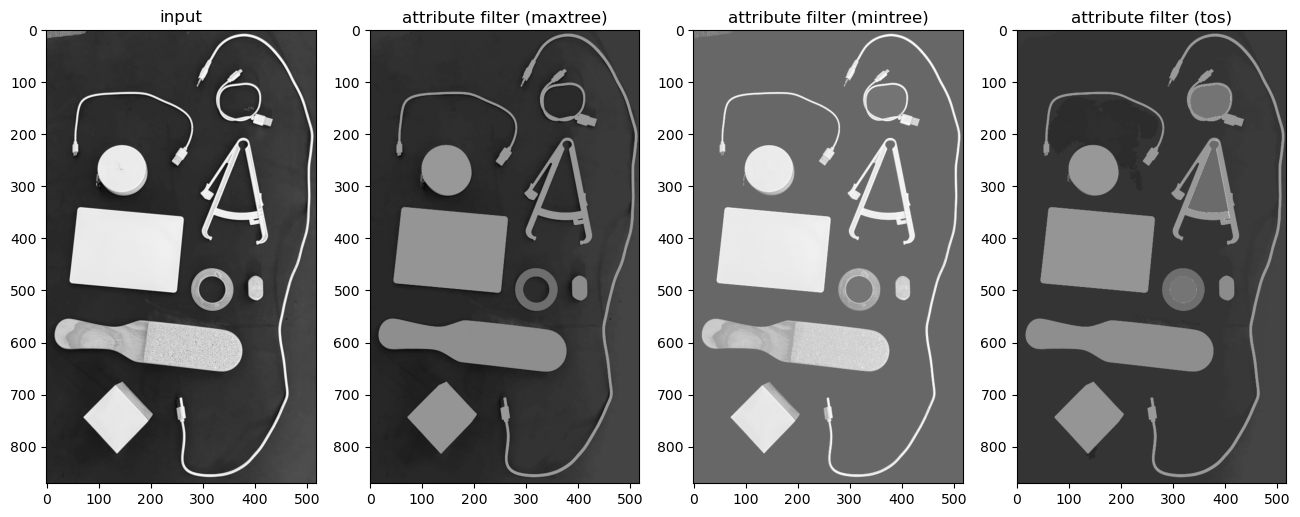

In [21]:
Type = mmcfilters.Attribute.Type
attrType = Type.GRAY_HEIGHT
threshold = 100

attr_maxtree = mmcfilters.Attribute.computeSingleAttribute(maxtree, attrType)
attr_mintree = mmcfilters.Attribute.computeSingleAttribute(mintree, attrType)
attr_tos = mmcfilters.Attribute.computeSingleAttribute(tos, attrType)

imgFilteredMaxtree = filterMaxtree.filteringDirectRule(attr_maxtree > threshold)
imgFilteredMintree = filterMintree.filteringDirectRule(attr_mintree > threshold)
imgFilteredToS = filterToS.filteringDirectRule(attr_tos > threshold)

plt.subplot(1,4, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(imgFilteredMaxtree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (maxtree)')

plt.subplot(1,4, 3)
plt.imshow(imgFilteredMintree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (mintree)')

plt.subplot(1,4, 4)
plt.imshow(imgFilteredToS.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')


==== AttributeComputer: Computing CENTRAL_MOMENT group

==== AttributeComputer: Computing MOMENT_BASED group

==== AttributeComputer: Computing CENTRAL_MOMENT group

==== AttributeComputer: Computing MOMENT_BASED group

==== AttributeComputer: Computing CENTRAL_MOMENT group

==== AttributeComputer: Computing MOMENT_BASED group


Text(0.5, 1.0, 'attribute filter (tos)')

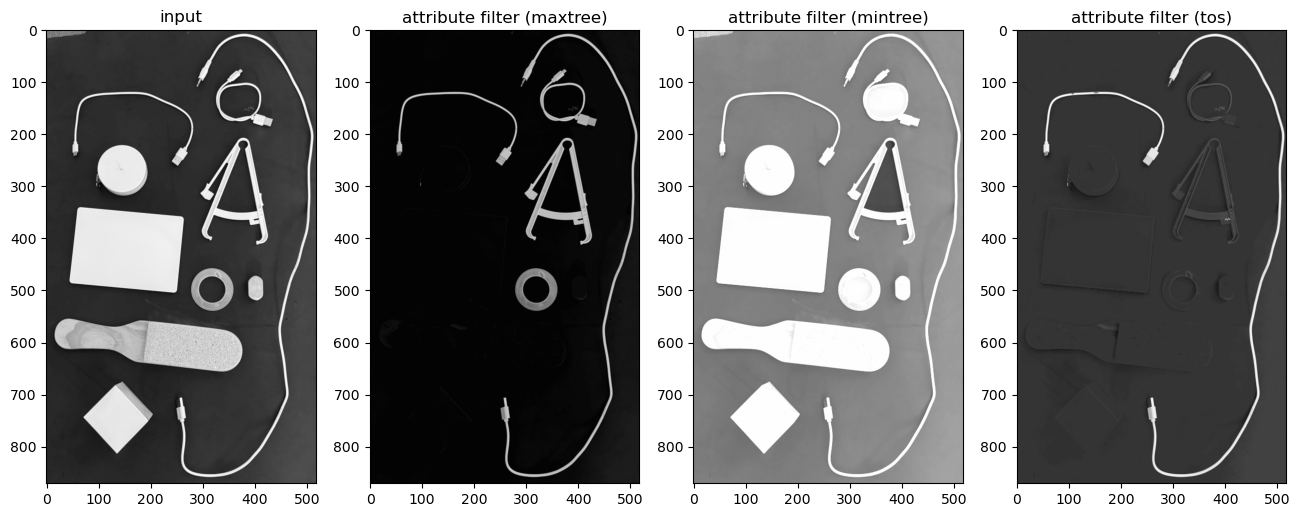

In [13]:
Type = mmcfilters.Attribute.Type
attrType = Type.INERTIA
threshold = 0.2

attr_maxtree = mmcfilters.Attribute.computeSingleAttribute(maxtree, attrType)
attr_mintree = mmcfilters.Attribute.computeSingleAttribute(mintree, attrType)
attr_tos = mmcfilters.Attribute.computeSingleAttribute(tos, attrType)

imgFilteredMaxtree = filterMaxtree.filteringSubtractiveRule(attr_maxtree > threshold)
imgFilteredMintree = filterMintree.filteringSubtractiveRule(attr_mintree > threshold)
imgFilteredToS = filterToS.filteringSubtractiveRule(attr_tos > threshold)

plt.subplot(1,4, 1)
plt.imshow(imgInput, cmap='gray', vmax=255, vmin=0)
plt.title('input')

plt.subplot(1,4, 2)
plt.imshow(imgFilteredMaxtree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (maxtree)')

plt.subplot(1,4, 3)
plt.imshow(imgFilteredMintree.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (mintree)')

plt.subplot(1,4, 4)
plt.imshow(imgFilteredToS.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('attribute filter (tos)')

In [35]:
Type = mmcfilters.Attribute.Type
attrType = Type.BOX_HEIGHT
threshold = 100

attr_maxtree = mmcfilters.Attribute.computeSingleAttribute(maxtree, attrType)
attr_mintree = mmcfilters.Attribute.computeSingleAttribute(mintree, attrType)
attr_tos = mmcfilters.Attribute.computeSingleAttribute(tos, attrType)

max_threshold = 500
deltaMSER=5
primitives = mmcfilters.AttributeOpeningPrimitivesFamily(maxtree, attr_maxtree, max_threshold)
primitives


==== AttributeComputer: Computing BOUNDING_BOX group

==== AttributeComputer: Computing BOUNDING_BOX group

==== AttributeComputer: Computing BOUNDING_BOX group


In [ ]:
Type = mmcfilters.Attribute.Type
attrType = Type.BOX_HEIGHT
threshold = 100

attr_maxtree = mmcfilters.Attribute.computeSingleAttribute(maxtree, attrType)
attr_mintree = mmcfilters.Attribute.computeSingleAttribute(mintree, attrType)
attr_tos = mmcfilters.Attribute.computeSingleAttribute(tos, attrType)

max_threshold = 500
deltaMSER=5
primitives = mmcfilters.AttributeOpeningPrimitivesFamily(maxtree, attr_maxtree, max_threshold)
#primitives = mmcfilters.AttributeOpeningPrimitivesFamily(mintree, attr_mintree, max_threshold)
#primitives = mmcfilters.AttributeOpeningPrimitivesFamily(tos, attr_tos, max_threshold)

rtree = mmcfilters.ResidualTree(primitives)
imgRest = primitives.restOfImage
imgRec = rtree.reconstruction()
imgPos = rtree.getPositiveResidues()
imgNeg = rtree.getNegativeResidues()

plt.subplot(1,4, 1)
plt.imshow(imgRec.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('input (rec)')

plt.subplot(1,4, 2)
plt.imshow(imgPos.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('positive residues')

plt.subplot(1,4, 3)
plt.imshow(imgNeg.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('negative residues')


In [ ]:
attr_type = dic['HU_MOMENT_1_INERTIA']
threshold = 0.18
att_tos = attrs_tos[:,attr_type]

filterToS = mmcfilters.AttributeFilters(tos)
imgAttrFilter = filterToS.filteringDirectRule(att_tos > threshold)
imgAttrSub = filterToS.filteringSubtractiveRule(att_tos > threshold)

primitives = mmcfilters.AttributeOpeningPrimitivesFamily(maxtree, attr_maxtree, max_threshold)
rtree = mmcfilters.ResidualTree(primitives)
imgResFilter = rtree.filtering(att_tos > threshold)

imgRec = rtree.reconstruction()

plt.subplot(1,4, 1)
plt.imshow(imgRec.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('input (rec)')

plt.subplot(1,4, 2)
plt.imshow(imgAttrFilter.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('direct filter')

plt.subplot(1,4, 3)
plt.imshow(imgAttrSub.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('subtractive filter')


plt.subplot(1,4, 4)
plt.imshow(imgResFilter.reshape(num_rows, num_cols), cmap='gray', vmax=255, vmin=0)
plt.title('residual filter')
